In [1]:
# The perceptron from the manual — exactly as specified
# Classifies a fruit as Apple or Not Apple
# based on weight (grams) and color (0 to 1 scale)

class Perceptron:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias    = bias

    def activation(self, x):
        # Step function (Hard-limit / Heaviside)
        # Returns 1 if weighted sum >= 0, else 0
        return 1 if x >= 0 else 0

    def predict(self, inputs):
        # Compute weighted sum + bias
        weighted_sum = sum(w * i for w, i in zip(self.weights, inputs)) + self.bias
        return self.activation(weighted_sum)

# Given values from lab manual
inputs  = [150, 0.9]       # weight=150g, color=0.9 (red-ish)
weights = [0.5, 1.0]       # strength of each feature
bias    = 1.5

# Create and run perceptron
perceptron = Perceptron(weights, bias)
output     = perceptron.predict(inputs)

print(f"Weighted Sum : (150 × 0.5) + (0.9 × 1.0) + 1.5 = {(150*0.5) + (0.9*1.0) + 1.5}")
print(f"Output       : {output}")
print(f"Prediction   : {'Apple' if output == 1 else 'Not an Apple'}")

Weighted Sum : (150 × 0.5) + (0.9 × 1.0) + 1.5 = 77.4
Output       : 1
Prediction   : Apple


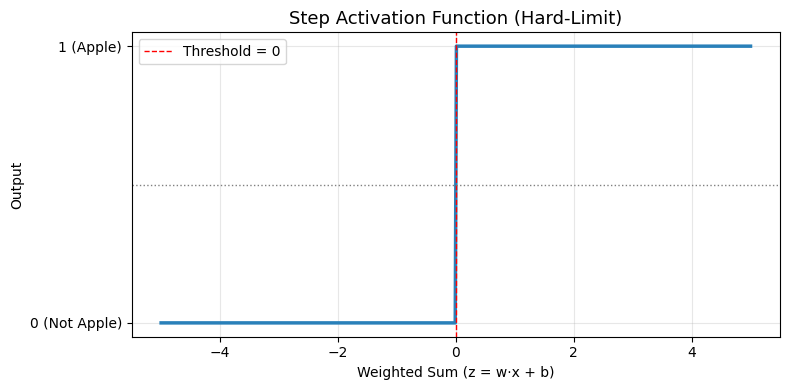

If z >= 0  →  output = 1  (Apple)
If z <  0  →  output = 0  (Not an Apple)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Plot the step (hard-limit) activation function
z = np.linspace(-5, 5, 500)
step_output = np.where(z >= 0, 1, 0)

plt.figure(figsize=(8, 4))
plt.plot(z, step_output, color='#2980b9', linewidth=2.5)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Threshold = 0')
plt.axhline(y=0.5, color='gray', linestyle=':', linewidth=1)
plt.title('Step Activation Function (Hard-Limit)', fontsize=13)
plt.xlabel('Weighted Sum (z = w·x + b)')
plt.ylabel('Output')
plt.yticks([0, 1], ['0 (Not Apple)', '1 (Apple)'])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("If z >= 0  →  output = 1  (Apple)")
print("If z <  0  →  output = 0  (Not an Apple)")

In [3]:
# Test the perceptron on multiple fruit samples
# to see how weight and color affect the prediction

test_cases = [
    ([150, 0.9], "Heavy + Very Red"),
    ([80,  0.8], "Light + Red"),
    ([200, 0.2], "Heavy + Green"),
    ([50,  0.1], "Light + Green"),
    ([120, 0.5], "Medium + Orange"),
]

print(f"{'Inputs':<25} {'Description':<20} {'Weighted Sum':>14} {'Output':>8} {'Prediction'}")
print("-" * 85)

for inputs_test, desc in test_cases:
    ws   = sum(w * i for w, i in zip(weights, inputs_test)) + bias
    out  = perceptron.predict(inputs_test)
    pred = "Apple" if out == 1 else "Not Apple"
    print(f"{str(inputs_test):<25} {desc:<20} {ws:>14.2f} {out:>8}   {pred}")

Inputs                    Description            Weighted Sum   Output Prediction
-------------------------------------------------------------------------------------
[150, 0.9]                Heavy + Very Red              77.40        1   Apple
[80, 0.8]                 Light + Red                   42.30        1   Apple
[200, 0.2]                Heavy + Green                101.70        1   Apple
[50, 0.1]                 Light + Green                 26.60        1   Apple
[120, 0.5]                Medium + Orange               62.00        1   Apple


In [4]:
# The lab manual mentions the "Perceptron Learning Rule"
# Here we implement it — the perceptron learns weights
# from data rather than using fixed given weights

class TrainablePerceptron:
    def __init__(self, n_inputs, learning_rate=0.1):
        # Initialize weights randomly, bias to 0
        self.weights       = np.random.randn(n_inputs) * 0.01
        self.bias          = 0.0
        self.learning_rate = learning_rate

    def activation(self, x):
        return 1 if x >= 0 else 0

    def predict(self, inputs):
        z = np.dot(self.weights, inputs) + self.bias
        return self.activation(z)

    def train(self, X, y, epochs=10):
        """
        Perceptron Learning Rule:
          error = true_label - predicted_label
          w = w + lr × error × x
          b = b + lr × error
        Updates only happen when a prediction is wrong.
        """
        history = []  # track accuracy per epoch

        for epoch in range(epochs):
            errors = 0
            for xi, yi in zip(X, y):
                pred  = self.predict(xi)
                error = yi - pred          # 0 if correct, ±1 if wrong

                # Update weights and bias
                self.weights += self.learning_rate * error * xi
                self.bias    += self.learning_rate * error

                if error != 0:
                    errors += 1

            accuracy = (len(X) - errors) / len(X) * 100
            history.append(accuracy)
            print(f"Epoch {epoch+1:>2}/{epochs} | Errors: {errors} | Accuracy: {accuracy:.1f}%")

        return history


# ── Train on AND gate ─────────────────────────────────────────────────────
# AND: output is 1 only when BOTH inputs are 1
X_and = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=float)
y_and = np.array([0, 0, 0, 1])

print("=== Training Perceptron on AND Gate ===\n")
p_and = TrainablePerceptron(n_inputs=2, learning_rate=0.1)
history_and = p_and.train(X_and, y_and, epochs=10)

print(f"\nLearned Weights : {p_and.weights}")
print(f"Learned Bias    : {p_and.bias:.4f}")

=== Training Perceptron on AND Gate ===

Epoch  1/10 | Errors: 2 | Accuracy: 50.0%
Epoch  2/10 | Errors: 3 | Accuracy: 25.0%
Epoch  3/10 | Errors: 1 | Accuracy: 75.0%
Epoch  4/10 | Errors: 0 | Accuracy: 100.0%
Epoch  5/10 | Errors: 0 | Accuracy: 100.0%
Epoch  6/10 | Errors: 0 | Accuracy: 100.0%
Epoch  7/10 | Errors: 0 | Accuracy: 100.0%
Epoch  8/10 | Errors: 0 | Accuracy: 100.0%
Epoch  9/10 | Errors: 0 | Accuracy: 100.0%
Epoch 10/10 | Errors: 0 | Accuracy: 100.0%

Learned Weights : [0.19945934 0.02753811]
Learned Bias    : -0.2000


In [5]:
print("=== AND Gate — Final Predictions ===\n")
print(f"{'Input A':<10} {'Input B':<10} {'Expected':<12} {'Predicted':<12} {'Correct?'}")
print("-" * 55)

for xi, yi in zip(X_and, y_and):
    pred    = p_and.predict(xi)
    correct = "✓" if pred == yi else "✗"
    print(f"{int(xi[0]):<10} {int(xi[1]):<10} {yi:<12} {pred:<12} {correct}")

=== AND Gate — Final Predictions ===

Input A    Input B    Expected     Predicted    Correct?
-------------------------------------------------------
0          0          0            0            ✓
0          1          0            0            ✓
1          0          0            0            ✓
1          1          1            1            ✓


In [6]:
# OR: output is 1 when AT LEAST ONE input is 1
X_or = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=float)
y_or = np.array([0, 1, 1, 1])

print("=== Training Perceptron on OR Gate ===\n")
p_or = TrainablePerceptron(n_inputs=2, learning_rate=0.1)
history_or = p_or.train(X_or, y_or, epochs=10)

print(f"\nLearned Weights : {p_or.weights}")
print(f"Learned Bias    : {p_or.bias:.4f}")

print("\n=== OR Gate — Final Predictions ===\n")
print(f"{'Input A':<10} {'Input B':<10} {'Expected':<12} {'Predicted':<12} {'Correct?'}")
print("-" * 55)
for xi, yi in zip(X_or, y_or):
    pred    = p_or.predict(xi)
    correct = "✓" if pred == yi else "✗"
    print(f"{int(xi[0]):<10} {int(xi[1]):<10} {yi:<12} {pred:<12} {correct}")

=== Training Perceptron on OR Gate ===

Epoch  1/10 | Errors: 2 | Accuracy: 50.0%
Epoch  2/10 | Errors: 2 | Accuracy: 50.0%
Epoch  3/10 | Errors: 2 | Accuracy: 50.0%
Epoch  4/10 | Errors: 1 | Accuracy: 75.0%
Epoch  5/10 | Errors: 0 | Accuracy: 100.0%
Epoch  6/10 | Errors: 0 | Accuracy: 100.0%
Epoch  7/10 | Errors: 0 | Accuracy: 100.0%
Epoch  8/10 | Errors: 0 | Accuracy: 100.0%
Epoch  9/10 | Errors: 0 | Accuracy: 100.0%
Epoch 10/10 | Errors: 0 | Accuracy: 100.0%

Learned Weights : [0.1082197  0.19236102]
Learned Bias    : -0.1000

=== OR Gate — Final Predictions ===

Input A    Input B    Expected     Predicted    Correct?
-------------------------------------------------------
0          0          0            0            ✓
0          1          1            1            ✓
1          0          1            1            ✓
1          1          1            1            ✓


In [7]:
# XOR: output is 1 when inputs are DIFFERENT
# This is NOT linearly separable — perceptron CANNOT learn it
X_xor = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

print("=== Training Perceptron on XOR Gate ===\n")
p_xor = TrainablePerceptron(n_inputs=2, learning_rate=0.1)
history_xor = p_xor.train(X_xor, y_xor, epochs=20)

print("\n=== XOR Gate — Final Predictions ===\n")
print(f"{'Input A':<10} {'Input B':<10} {'Expected':<12} {'Predicted':<12} {'Correct?'}")
print("-" * 55)
for xi, yi in zip(X_xor, y_xor):
    pred    = p_xor.predict(xi)
    correct = "✓" if pred == yi else "✗"
    print(f"{int(xi[0]):<10} {int(xi[1]):<10} {yi:<12} {pred:<12} {correct}")

print("\nXOR cannot be solved by a single-layer perceptron.")
print("It is not linearly separable — no single line can separate the classes.")
print("This limitation led to the invention of multi-layer networks (MLP).")

=== Training Perceptron on XOR Gate ===

Epoch  1/20 | Errors: 3 | Accuracy: 25.0%
Epoch  2/20 | Errors: 3 | Accuracy: 25.0%
Epoch  3/20 | Errors: 4 | Accuracy: 0.0%
Epoch  4/20 | Errors: 4 | Accuracy: 0.0%
Epoch  5/20 | Errors: 4 | Accuracy: 0.0%
Epoch  6/20 | Errors: 4 | Accuracy: 0.0%
Epoch  7/20 | Errors: 4 | Accuracy: 0.0%
Epoch  8/20 | Errors: 4 | Accuracy: 0.0%
Epoch  9/20 | Errors: 4 | Accuracy: 0.0%
Epoch 10/20 | Errors: 4 | Accuracy: 0.0%
Epoch 11/20 | Errors: 4 | Accuracy: 0.0%
Epoch 12/20 | Errors: 4 | Accuracy: 0.0%
Epoch 13/20 | Errors: 4 | Accuracy: 0.0%
Epoch 14/20 | Errors: 4 | Accuracy: 0.0%
Epoch 15/20 | Errors: 4 | Accuracy: 0.0%
Epoch 16/20 | Errors: 4 | Accuracy: 0.0%
Epoch 17/20 | Errors: 4 | Accuracy: 0.0%
Epoch 18/20 | Errors: 4 | Accuracy: 0.0%
Epoch 19/20 | Errors: 4 | Accuracy: 0.0%
Epoch 20/20 | Errors: 4 | Accuracy: 0.0%

=== XOR Gate — Final Predictions ===

Input A    Input B    Expected     Predicted    Correct?
-----------------------------------------

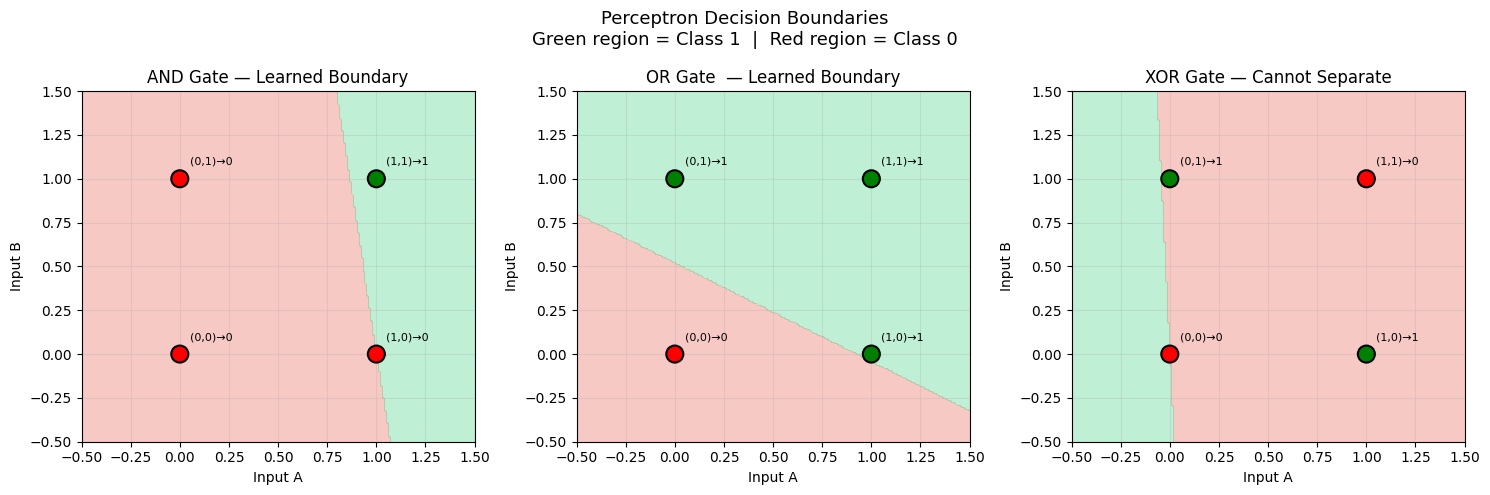

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Decision boundary helper ───────────────────────────────────────────────
def plot_decision_boundary(ax, perceptron, X, y, title):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid   = np.c_[xx.ravel(), yy.ravel()]
    Z      = np.array([perceptron.predict(pt) for pt in grid])
    Z      = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, colors=['#e74c3c', '#2ecc71'], levels=[-0.5, 0.5, 1.5])
    colors = ['red' if label == 0 else 'green' for label in y]
    ax.scatter(X[:,0], X[:,1], c=colors, s=150, zorder=5,
               edgecolors='black', linewidths=1.5)

    for i, (xi, yi) in enumerate(zip(X, y)):
        ax.annotate(f'({int(xi[0])},{int(xi[1])})→{yi}',
                    xy=(xi[0], xi[1]), xytext=(xi[0]+0.05, xi[1]+0.08),
                    fontsize=8)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('Input A')
    ax.set_ylabel('Input B')
    ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.3)

plot_decision_boundary(axes[0], p_and, X_and, y_and, 'AND Gate — Learned Boundary')
plot_decision_boundary(axes[1], p_or,  X_or,  y_or,  'OR Gate  — Learned Boundary')
plot_decision_boundary(axes[2], p_xor, X_xor, y_xor, 'XOR Gate — Cannot Separate')

plt.suptitle('Perceptron Decision Boundaries\nGreen region = Class 1  |  Red region = Class 0',
             fontsize=13)
plt.tight_layout()
plt.show()

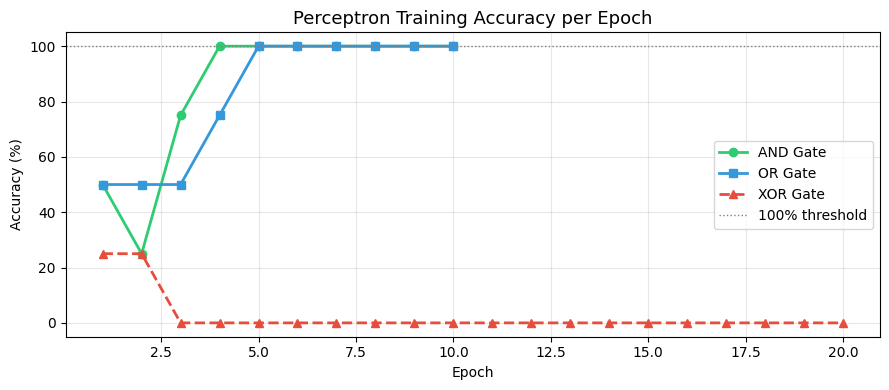

AND and OR converge to 100% — linearly separable.
XOR never reaches 100% — not linearly separable.


In [9]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, 11), history_and, marker='o', label='AND Gate', color='#2ecc71', linewidth=2)
plt.plot(range(1, 11), history_or,  marker='s', label='OR Gate',  color='#3498db', linewidth=2)
plt.plot(range(1, 21), history_xor, marker='^', label='XOR Gate', color='#e74c3c', linewidth=2,
         linestyle='--')
plt.axhline(y=100, color='gray', linestyle=':', linewidth=1, label='100% threshold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Perceptron Training Accuracy per Epoch', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("AND and OR converge to 100% — linearly separable.")
print("XOR never reaches 100% — not linearly separable.")

In [10]:
print("=" * 55)
print("     EXPERIMENT 1 — FINAL SUMMARY")
print("=" * 55)
print()
print("Perceptron Components:")
print("  Input layer    : raw feature values")
print("  Weights        : strength of each input connection")
print("  Bias           : shifts the decision threshold")
print("  Weighted sum   : z = Σ(wᵢ × xᵢ) + b")
print("  Activation     : step function → 0 or 1")
print()
print("Lab Manual Task (Apple/Not Apple):")
print("  z = (150×0.5) + (0.9×1.0) + 1.5 = 76.4")
print("  76.4 >= 0  →  output = 1  →  Apple ✓")
print()
print("Logic Gate Results:")
print(f"  AND Gate  : Converged  → 100% accuracy")
print(f"  OR Gate   : Converged  → 100% accuracy")
print(f"  XOR Gate  : Failed     → cannot converge")
print()
print("Key Limitation:")
print("  A single-layer perceptron can only learn")
print("  LINEARLY SEPARABLE problems.")
print("  XOR requires a multi-layer network (MLP).")
print("  This motivated the invention of backpropagation")
print("  and deep learning.")
print("=" * 55)

     EXPERIMENT 1 — FINAL SUMMARY

Perceptron Components:
  Input layer    : raw feature values
  Weights        : strength of each input connection
  Bias           : shifts the decision threshold
  Weighted sum   : z = Σ(wᵢ × xᵢ) + b
  Activation     : step function → 0 or 1

Lab Manual Task (Apple/Not Apple):
  z = (150×0.5) + (0.9×1.0) + 1.5 = 76.4
  76.4 >= 0  →  output = 1  →  Apple ✓

Logic Gate Results:
  AND Gate  : Converged  → 100% accuracy
  OR Gate   : Converged  → 100% accuracy
  XOR Gate  : Failed     → cannot converge

Key Limitation:
  A single-layer perceptron can only learn
  LINEARLY SEPARABLE problems.
  XOR requires a multi-layer network (MLP).
  This motivated the invention of backpropagation
  and deep learning.
